In [1]:
from utils import load_TO_runs, set_plt_template, plot_convergence_per_simulation, plot_convergence_per_total

import numpy as np
import matplotlib.pyplot as plt
set_plt_template()

In [3]:
n_BBOB = 24
n_BBOB_instances = 5
n_BBOB_repeats = 5

n_TO = 3
n_TO_repeats = 15
parameterizations = ('mmc', 'guo', 'hex')
parameterization2fid = {p : n_BBOB + (i+1) for (i, p) in enumerate(parameterizations)}

dimensions = (10, 20, 50)
optimizers = ('CMAES', 'HEBO', 'DE')
meta_features = ['fid', 'instance', 'seed']

budget = lambda dimension : 20*dimension

colors = {'CMAES': 'C0', 'HEBO': 'C1', 'DE': 'C2'}
linestyles = {'guo': '-', 'mmc': '--', 'hex': ':'}
labels = {'mmc': 'MMC', 'guo': 'Curved MMC', 'hex': 'Honeycomb'}

In [12]:
path = '../results/'

runs = {
    dimension : {
        optimizer : {
            parameterization : load_TO_runs(parameterization, dimension, optimizer, path) 
            for parameterization in parameterizations
        } for optimizer in optimizers
    } for dimension in dimensions
}

In [18]:
# !mkdir ./figures

# Convergence Figures

## Total Evaluations

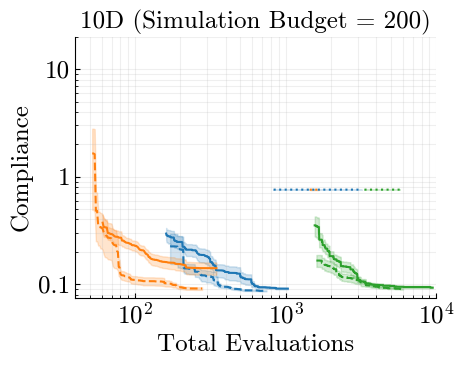

In [21]:
(fig, ax) = plot_convergence_per_total(
    10, optimizers, parameterizations, runs, 
)
ax.set_xlim(40, 1e4)
ax.set_ylim(0.075, 20)
ax.set_yticks([0.1, 1, 10], [0.1, 1, 10])

fig.savefig('./figures/total-10D.png')

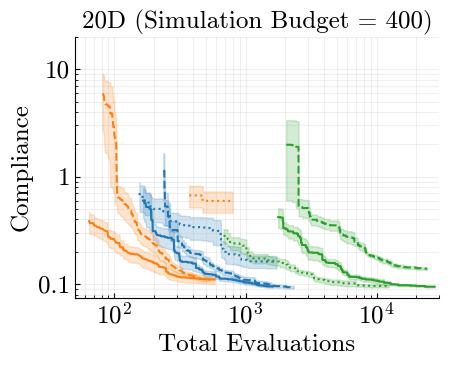

In [23]:
(fig, ax) = plot_convergence_per_total(
    20, optimizers, parameterizations, runs, 
)
ax.set_xlim(5e1, 3e4)
ax.set_ylim(0.075, 20)
ax.set_yticks([0.1, 1, 10], [0.1, 1, 10])
fig.savefig('./figures/total-20D.png')

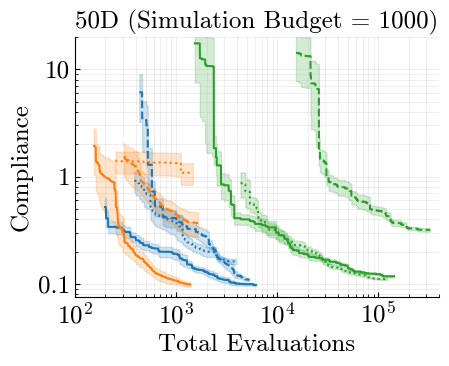

In [24]:
(fig, ax) = plot_convergence_per_total(
    50, optimizers, parameterizations, runs, 
)
ax.set_xlim(1e2, 4e5)
ax.set_ylim(0.075, 20)
ax.set_yticks([0.1, 1, 10], [0.1, 1, 10])
fig.savefig('./figures/total-50D.png')

## Simulation Calls

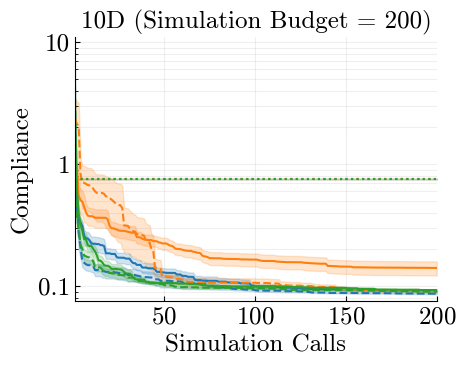

In [26]:
(fig, ax) = plot_convergence_per_simulation(
    10, optimizers, parameterizations, runs, 
)
ax.set_ylim(0.075, 11)
ax.set_yticks([0.1, 1, 10], [0.1, 1, 10])
fig.savefig('./figures/simulation-10D.png')

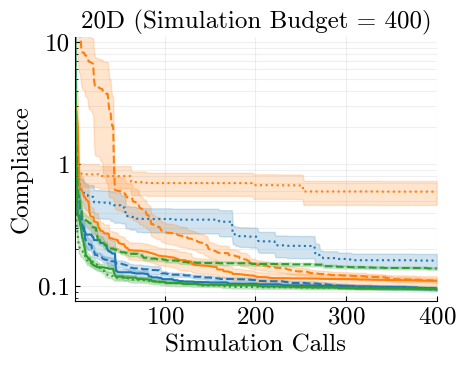

In [27]:
(fig, ax) = plot_convergence_per_simulation(
    20, optimizers, parameterizations, runs, 
)
ax.set_ylim(0.075, 11)
ax.set_yticks([0.1, 1, 10], [0.1, 1, 10])
fig.savefig('./figures/simulation-20D.png')

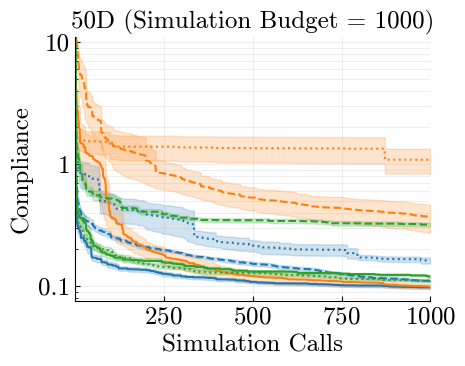

In [28]:
(fig, ax) = plot_convergence_per_simulation(
    50, optimizers, parameterizations, runs, 
)
ax.set_ylim(0.075, 11)
ax.set_yticks([0.1, 1, 10], [0.1, 1, 10])
fig.savefig('./figures/simulation-50D.png')

# Final Distributions